In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Despite the term 'regression' being part of its name, logistic regression is considered as a classification algorithm. This naming can often lead to confusion, particularly when contrasted with linear regression. In Chapter 10.7 of the textbook (Alpaydin, 3rd ed.), the mathematical formulation for logistic regression is presented as:

$$y = \frac{1}{1 + \exp[-(w^T x + w_0)]}$$

We can rewrite this expression using the sigmoid function, denoted by $\sigma(\cdot)$, as follows:

$$y = \sigma(w^T x + w_0)$$

In the formula, the term $w^T x + w_0$ can be viewed as a linear decision boundary hyperplane that splits the input space into two regions. The sigmoid function then maps each region into a label space ranging from $(0, 1)$, with the boundary located at the midpoint of $0.5$.

* **(1a)** Generate five bivariate instances for each of two normal distributions, with each distribution representing a distinct class: $\mathcal{N}(\mu_1, \Sigma_1)$ and $\mathcal{N}(\mu_2, \Sigma_2)$. Let $\mu_1 = [0, 0]^T$, $\mu_2 = [1, 1]^T$, and both $\Sigma_1$ and $\Sigma_2$ be identity matrices. Plot these instances on a Cartesian plane. Then, introduce an arbitrary linear decision boundary, represented by $w^T x + w_0$. The boundary should efficiently differentiate between the two classes.

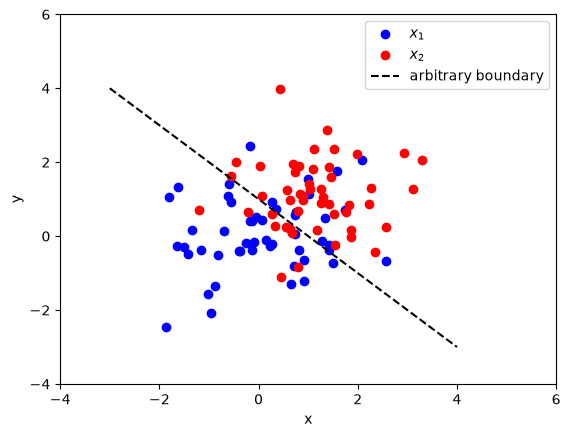

In [26]:
mean_1, mean_2 = [0, 0], [1, 1]
cov = np.identity(2) # = np.array([[1, 0], [0, 1]])

x_1, y_1 = np.random.multivariate_normal(mean_1, cov, 50).T
x_2, y_2 = np.random.multivariate_normal(mean_2, cov, 50).T

# arbitrary decision boundary
# we choose w such that the cross entropy loss function is minimised
w = np.array([1.0, 1.0])
w_0 = -1

x_1_min = min(x_1.min(), x_1.min()) - 1
x_1_max = max(x_2.max(), x_2.max()) + 1
x_line = np.linspace(-3, 4, 100)
y_line = (-w[0]* x_line - w_0)/w[1] 

fig, ax1 = plt.subplots()
#first distribution
color_1 = 'blue'
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.scatter(x_1, y_1, color=color_1, label='$x_1$')
#second distribution
color_2 = 'red'
ax1.scatter(x_2, y_2, color=color_2, label='$x_2$')
# boundary
ax1.plot(x_line, y_line, color='black', linestyle='--', label='arbitrary boundary')
ax1.legend()
ax1.set_ylim(-4 , 6)
ax1.set_xlim(-4 , 6)
plt.show()


* **(1b)** Transform the Cartesian plane into a three-dimensional space by adding a $z$-axis, which represents the output of the sigmoid function, ranging from $(0, 1)$. Note that the linear decision boundary in the Cartesian plane corresponds to the midpoint of $0.5$ on the $z$-axis. The instances sampled from the $\mathcal{N}(\mu_1, \Sigma_1)$ distribution, which represents class 1, should yield a sigmoid output close to $0$. Conversely, the instances from the $\mathcal{N}(\mu_2, \Sigma_2)$ distribution, representing class 2, should have a sigmoid output close to $1$.

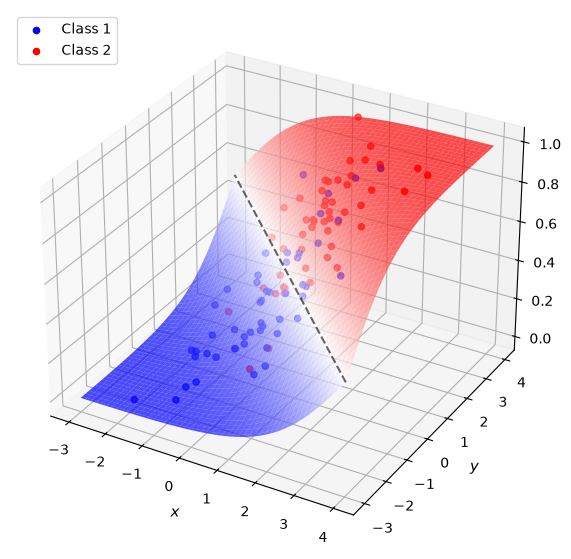

In [27]:
#define sigmoid function
def sigmoid(z):
    return 1/ (1 + np.exp(-z))

#computing the z values for each sample cluster
z_1 = sigmoid(w[0] * x_1 + w[1] * y_1 + w_0)
z_2 = sigmoid(w[0] * x_2 + w[1] * y_2 + w_0)

# building 2D mesh grid and evaluating the 3D sigmoid surface
X_grid, Y_grid = np.meshgrid(x_line, y_line)
Z_surface = sigmoid(w[0] * X_grid + w[1] * Y_grid + w_0)

#3D plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

#plot sigmoid surface
ax.plot_surface(X_grid, Y_grid, Z_surface, cmap="bwr", alpha=0.7)

#Scatter 3D mapped points
ax.scatter(x_1, y_1, z_1, color=color_1, label='Class 1')
ax.scatter(x_2, y_2, z_2, color=color_2, label='Class 2')
#plot boudary at z = 0.5
ax.contour(X_grid, Y_grid, Z_surface, levels=[0.5], colors='black', linestyles='--', alpha=0.6)

ax.set_xlabel("$x$", fontsize=11)
ax.set_ylabel("$y$", fontsize=11)
ax.legend(loc="upper left")

plt.show()

* **(1c)** Assume that the linear decision boundary in (1a) is ineffective, leading to an estimated accuracy of around $50\%$. Replicate the process in (1b) using this ineffective decision boundary.

* **(1d)** Elaborate on the appropriate choice of the loss function for this binary classification task by discussing the differences and implications seen in the visualizations from (1b) and (1c).


* **(1e)** The schematic mechanism of a single neuron consists of inputs $x_1, \dots, x_n$ weighted by $w_1, \dots, w_n$, summed together ($\sum_{j=1}^n x_j w_j$), and passed through an activation function to produce output $y$. Elaborate on the relevance between this neuron and logistic regression.